In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set()
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('../data/gym_churn_us.csv')
data.columns = data.columns.str.lower().str.strip().str.replace(' ', '_')

In [3]:
print(f"Churn rate is: {data['churn'].mean()*100:.2f}%")

Churn rate is: 26.52%


Checking the frequency drop towards quiting  
&darr; &darr; &darr;

In [4]:
data.groupby('churn')[['avg_class_frequency_total','avg_class_frequency_current_month']].mean()

,avg_class_frequency_total,avg_class_frequency_current_month
churn,,
0,2.024876,2.027882
1,1.474995,1.044546


In [5]:
data['frequency_drop'] = data['avg_class_frequency_total'] - data['avg_class_frequency_current_month']

<Axes: xlabel='frequency_drop', ylabel='Density'>

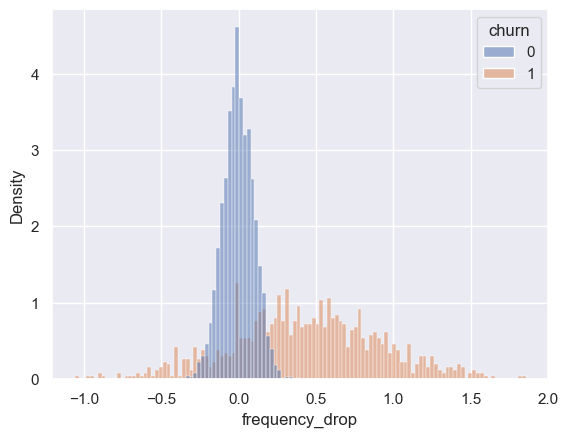

In [6]:
sns.histplot(data=data, x='frequency_drop', hue='churn', stat='density', common_norm=False)

&uarr; &uarr; &uarr;  
We can see a decline on visit frequency towards quiting

##### Categorical parameters

In [7]:
data.groupby('gender')['churn'].agg(churn_rate='mean',
                                  count= 'count',)

,churn_rate,count
gender,,
0,0.264931,1959
1,0.265556,2041


In [8]:
data.groupby('partner')['churn'].agg(churn_rate='mean', 
                                   count= 'count')

,churn_rate,count
partner,,
0,0.333171,2053
1,0.193631,1947


In [9]:
data.groupby('promo_friends')['churn'].agg(churn_rate='mean', 
                                   count= 'count')

,churn_rate,count
promo_friends,,
0,0.313087,2766
1,0.158023,1234


In [10]:
data.groupby('group_visits')['churn'].agg(churn_rate='mean', 
                                   count= 'count')

,churn_rate,count
group_visits,,
0,0.330072,2351
1,0.172832,1649


In [11]:
data.groupby('near_location')['churn'].agg(churn_rate='mean', 
                                   count= 'count')

,churn_rate,count
near_location,,
0,0.397415,619
1,0.241053,3381


In [12]:
data.groupby('contract_period')['churn'].agg(churn_rate='mean', 
                                           count= 'count')

,churn_rate,count
contract_period,,
1,0.423199,2207
6,0.124850,833
12,0.023958,960


In [13]:
data['age_group'] = pd.cut(data['age'],
                         bins=(17, 25, 35, np.inf), 
                         labels=('18-25','26-35','36+'))

data.groupby('age_group')['churn'].agg(churn_rate='mean', 
                                     count='count')

,churn_rate,count
age_group,,
18-25,0.619403,536
26-35,0.215832,3373
36+,0.010989,91


In [14]:
data.groupby('churn')[['lifetime','avg_additional_charges_total']].mean()

,lifetime,avg_additional_charges_total
churn,,
0,4.711807,158.445715
1,0.990575,115.082899


In [15]:
df_result = data.groupby(['age_group','contract_period']).agg(count=('churn','size'), 
                                                            churn_rate=('churn','mean'), 
                                                            )

df_result['contract_rate'] = df_result['count'].groupby(level=0).transform(lambda x: x/x.sum())

df_result

count  churn_rate  contract_rate
age_group contract_period                                  
18-25     1                  367    0.782016       0.684701
          6                   87    0.459770       0.162313
          12                  82    0.060976       0.152985
26-35     1                 1800    0.358889       0.533650
          6                  720    0.088889       0.213460
          12                 853    0.021102       0.252891
36+       1                   40    0.025000       0.439560
          6                   26    0.000000       0.285714
          12                  25    0.000000       0.274725

In [16]:
data.to_csv('../data/gym_churn_us_clean.csv', index=False)